# 09 — `add_noise`: gauss / white / pink / brown

Each takes a clean signal and returns `signal + noise` of the
named type.

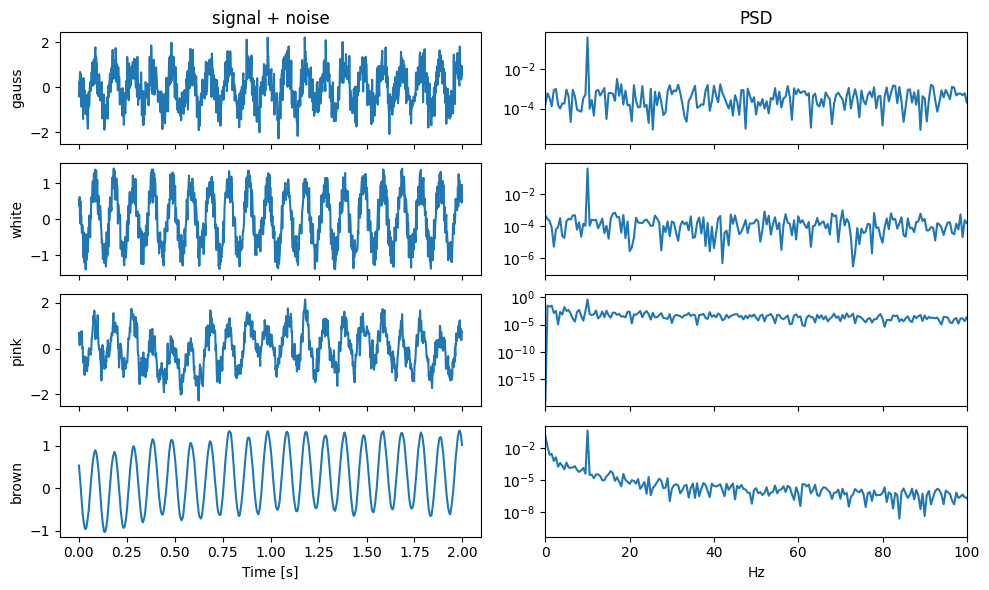

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import scitex_dsp as dsp
%matplotlib inline

xx, tt, fs = dsp.demo_sig(sig_type="periodic", batch_size=1, n_chs=1,
                          t_sec=2, fs=512, freqs_hz=[10])
kinds = {"gauss": dsp.add_noise.gauss, "white": dsp.add_noise.white,
         "pink":  dsp.add_noise.pink,  "brown": dsp.add_noise.brown}

fig, axes = plt.subplots(len(kinds), 2, figsize=(10, 6), sharex="col")
for (name, fn), row in zip(kinds.items(), axes):
    yy = np.asarray(fn(xx, amp=0.5))
    pp, ff = dsp.psd(yy, fs=fs)
    row[0].plot(tt, yy[0, 0]); row[0].set_ylabel(name)
    row[1].semilogy(np.asarray(ff), np.asarray(pp)[0, 0])
    row[1].set_xlim(0, 100)
axes[-1, 0].set_xlabel("Time [s]"); axes[-1, 1].set_xlabel("Hz")
axes[0, 0].set_title("signal + noise"); axes[0, 1].set_title("PSD")
fig.tight_layout()
plt.show()
